### load dataset

In [12]:
import pandas as pd
df = pd.read_csv('sample_kinder_data.csv')

### check for duplicates
22 duplicates but we decided to keep them as is because there is no primary key to differenciate the rows, we might be deleting rows that are important

In [ ]:
df.duplicated().sum()

### 🧩 Check for Missing Data

Missing data can cause issues in analysis and model performance, so it’s important to identify where they occur and decide how to handle them.

**Findings & Decisions:**

- **Missing target variables (`score_read`, `score_math`):**  
  We decided to **remove** these rows because the target variable is what we are trying to predict.  
  Keeping rows without actual target values would not contribute to training or evaluation and could bias results.

- **Missing numerical variables:**  
  We filled these using either the **mean or median**, depending on the **skewness** of the variable.  
  - If the variable was approximately symmetric (|skew| ≤ 1), we used the **mean**.  
  - If it was highly skewed (|skew| > 1), we used the **median**, since it is less affected by extreme values.

- **Missing categorical variables:**  
  We replaced these with the label **"Unknown"**.  
  This allows us to retain all records while still capturing the fact that the value was missing, which may itself hold information.

**Reasoning:**  
This approach ensures that the dataset remains complete for analysis and modeling, avoids dropping too many rows, and minimizes bias from missing data patterns.


In [15]:
df.isnull().sum()
(df.isnull().sum()/len(df))*100  # percentage missing

score_read            8.241107
score_math            6.996047
gender                0.000000
birth                 0.098814
lunch                 0.415020
ethnicity             0.019763
class_type            0.000000
school                0.000000
degree                0.375494
ladder               10.098814
experience            0.375494
t_ethnicity           1.027668
schooldistrict_id     0.000000
school_id             0.000000
dtype: float64

In [17]:
# Drop rows with missing target variables
df.dropna(subset=['score_read', 'score_math'], inplace=True)

# Identify numeric and categorical columns
numeric_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(exclude=['number']).columns

# Handle missing values in numeric columns
# Use median if skewed, mean if approximately symmetric
for col in numeric_cols:
    if abs(df[col].skew()) > 1:
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mean())

# Handle missing values in categorical columns
# Fill missing categories with 'Unknown' for interpretability
for col in categorical_cols:
    df[col] = df[col].fillna('Unknown')
    
# Verify no missing values remain
print(df.isnull().sum())


score_read           0
score_math           0
gender               0
birth                0
lunch                0
ethnicity            0
class_type           0
school               0
degree               0
ladder               0
experience           0
t_ethnicity          0
schooldistrict_id    0
school_id            0
dtype: int64


### 🔍 Check for Incorrect Data Types

Data types tell us how the values in each column are stored and interpreted by Python and Pandas.  
Having the correct data type is important because it affects how the data can be analyzed and modeled.

**Common Data Types in Pandas:**
- **`float64`** → Numeric values with decimals (e.g., 12.5, 3.14).  
  Used for continuous numerical data — suitable for calculations like mean, median, and correlation.
- **`int64`** → Whole numbers (e.g., 1, 25, 100).  
  Used for counts or discrete numeric variables.
- **`object`** → Usually text or categorical values (e.g., 'Male', 'Small', 'Quarter 1').  
  It can also contain numbers stored as text, which can cause problems in numeric analysis.

**Why check this:**  
- If numeric data (like scores or ages) are stored as `object`, you can’t perform calculations correctly.  
- If categorical data (like gender or region) are stored as numeric, models may treat them incorrectly as continuous features.


In [18]:
df.dtypes


score_read           float64
score_math           float64
gender                object
birth                 object
lunch                 object
ethnicity             object
class_type            object
school                object
degree                object
ladder                object
experience           float64
t_ethnicity           object
schooldistrict_id    float64
school_id            float64
dtype: object

### 📊 Explore Numeric Distributions

**Why:**  
Exploring numeric distributions helps us understand how each variable is spread — whether it’s normally distributed, skewed, or contains outliers.  
This is an essential step before modeling because some algorithms (like linear regression) assume normality, while others are more robust to skewed data.

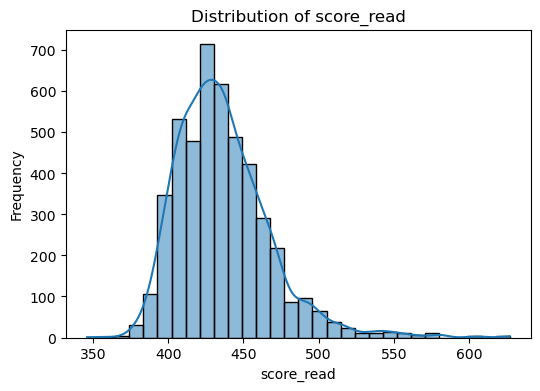

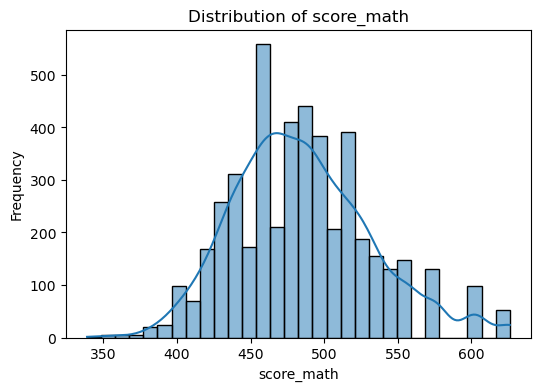

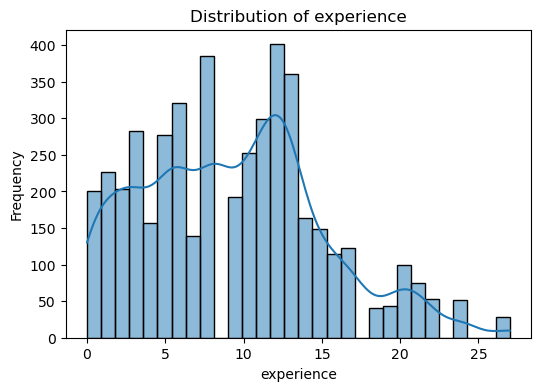

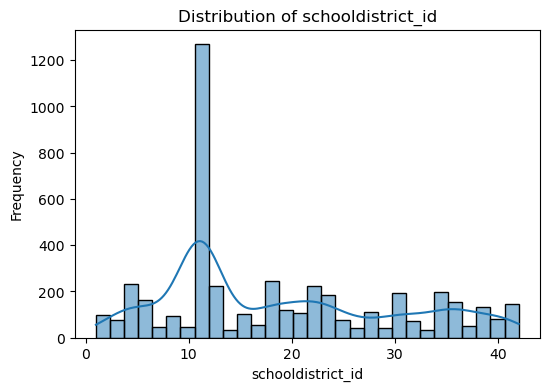

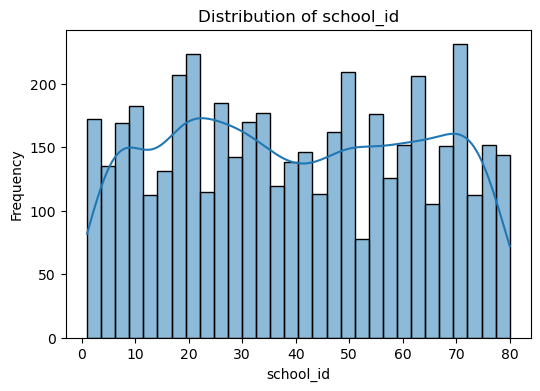

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot histograms with KDE for each numeric column
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}", fontsize=12)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


### 📈 Check Skewness and Kurtosis — Interpretation & Action

**Purpose:**  
Skewness measures asymmetry — how uneven the data is around its mean.  
Kurtosis measures "tailedness" — how heavy or light the tails are compared to a normal distribution.  
Together, they help identify whether the data is normally distributed or if transformations may be needed.

---

**Findings:**

- **score_read:**  
  - Skewness = **1.31** → Highly **right-skewed** (most students scored lower, few very high performers).  
  - Kurtosis = **3.69** → **Heavy-tailed and peaked** distribution (presence of extreme outliers).  
  - Since this is one of our **target variables**, the skewness and high kurtosis indicate that the outcome is not perfectly normal.

- **score_math:**  
  - Skewness = **0.49**, Kurtosis = **0.25** → Approximately **normal distribution**, no issues.  

- **schooldistrict_id:**  
  - Skewness = **0.54**, Kurtosis = **-0.90** → Mild right skew, flatter tails, acceptable.  

- **experience:**  
  - Skewness = **0.43**, Kurtosis = **-0.22** → Roughly symmetric and flat, acceptable.  

- **school_id:**  
  - Skewness = **0.03**, Kurtosis = **-1.23** → Symmetric with flat distribution, acceptable.  

---

**Actions:**
- We will first **keep `score_read` as it is** for initial modeling.  
- After building the model, we will **check the residuals**:  
  - If residuals are non-normal or variance is unstable, apply a **log** or **Yeo-Johnson transformation** to normalize the target.  
- Tree-based models (e.g., Random Forest, XGBoost) are robust to skewness and kurtosis, so no transformation is required.  
- Linear models (e.g., OLS, Ridge, Lasso) may benefit from transformation to stabilize variance and improve predictive accuracy.  
- All other variables have acceptable skewness and kurtosis, so **no action** is required.

---

**Summary:**  
`score_read` shows noticeable asymmetry and heavy tails, suggesting a few extreme high-performing students.  
If modeling results show poor residual normality, we will revisit this variable for transformation.  
Otherwise, the remaining numeric features are sufficiently normal for analysis.




In [23]:
import pandas as pd
from scipy.stats import skew, kurtosis


# Create a DataFrame with skewness and kurtosis for each numeric variable
dist_stats = pd.DataFrame({
    'Skewness': df[numeric_cols].apply(lambda x: skew(x.dropna())),
    'Kurtosis': df[numeric_cols].apply(lambda x: kurtosis(x.dropna()))
})

print(dist_stats.sort_values(by='Skewness', ascending=False))


                   Skewness  Kurtosis
score_read         1.319511  3.689024
schooldistrict_id  0.537265 -0.898049
score_math         0.496615  0.253082
experience         0.426944 -0.217282
school_id          0.026882 -1.230518


### 🚨 Outlier Detection (IQR Method)

**Why:**  
Outliers can indicate unusual or extreme values that may distort model training if not addressed.

**Method Used:**  
Applied the **IQR (Interquartile Range)** rule:  
Values below Q1 − 1.5×IQR or above Q3 + 1.5×IQR are considered outliers.

**Findings:**
| Variable | Lower Bound | Upper Bound | % of Outliers | Interpretation |
|-----------|--------------|--------------|----------------|----------------|
| score_math | 365.5 | 601.5 | 3.49% | Mild; valid low/high achievers |
| score_read | 355.5 | 511.5 | 2.46% | Mild; expected from right-skew |
| experience | -7 | 25 | 0.6% | Minor; realistic variation |
| schooldistrict_id | -13 | 51 | 0% | None |
| school_id | -40 | 120 | 0% | None |

**Action:**
- No removal performed — all outliers appear **valid** rather than erroneous.
- For modeling:
  - Tree-based models can use data directly.
  - Linear models may benefit from transformation of `score_read` to reduce skew.
- Outlier summary and rationale documented for transparency.


In [29]:
iqr_rows = []
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    mask = (df[col] < lower) | (df[col] > upper)
    iqr_rows.append({
        'column': col,
        'Q1': q1, 'Q3': q3, 'IQR': iqr,
        'lower_1.5IQR': lower,
        'upper_1.5IQR': upper,
        'n_outliers': int(mask.sum()),
        'pct_outliers': round(100 * mask.mean(), 2)
    })

iqr_summary = pd.DataFrame(iqr_rows).sort_values('n_outliers', ascending=False)
print("IQR outlier summary (1.5×IQR rule):")
display(iqr_summary)

# (optional) example rows for the top IQR outlier column
if not iqr_summary.empty:
    top_col_iqr = iqr_summary.iloc[0]['column']
    q1 = iqr_summary.iloc[0]['Q1']; q3 = iqr_summary.iloc[0]['Q3']
    iqr = iqr_summary.iloc[0]['IQR']
    lower = iqr_summary.iloc[0]['lower_1.5IQR']; upper = iqr_summary.iloc[0]['upper_1.5IQR']
    mask = (df[top_col_iqr] < lower) | (df[top_col_iqr] > upper)
    print(f"Example rows with IQR outliers in '{top_col_iqr}':")
    display(df.loc[mask, [top_col_iqr]].head(10))


IQR outlier summary (1.5×IQR rule):


,column,Q1,Q3,IQR,lower_1.5IQR,upper_1.5IQR,n_outliers,pct_outliers
1,score_math,454.0,513.0,59.0,365.5,601.5,162,3.49
0,score_read,414.0,453.0,39.0,355.5,511.5,114,2.46
2,experience,5.0,13.0,8.0,-7.0,25.0,28,0.60
3,schooldistrict_id,11.0,27.0,16.0,-13.0,51.0,0,0.00
4,school_id,20.0,60.0,40.0,-40.0,120.0,0,0.00


Example rows with IQR outliers in 'score_math':


,score_math
0,602.0
64,626.0
166,626.0
210,626.0
336,602.0
356,602.0
503,602.0
545,626.0
606,602.0
607,602.0


### 🔗 Correlation Analysis

**Why:**  
To identify the strength and direction of linear relationships between numeric variables,  
and to check for multicollinearity before modeling.

**Method:**  
Used the Pearson correlation coefficient and visualized via heatmap.

**Key Findings:**
- `score_read` and `score_math` show a **strong positive correlation (r = 0.71)** —  
  students who perform well in reading also tend to perform well in math.
- `school_id` and `schooldistrict_id` show an **extremely high correlation (r = 0.97)** —  
  these features carry duplicate information, likely due to hierarchical coding.  
  → Only one should be used in modeling to avoid multicollinearity.
- `experience` shows weak correlations (~0.1) with scores — limited linear effect on performance.
- Other relationships are very weak (<0.1), suggesting minimal linear association.

**Actions:**
- Retain both `score_read` and `score_math` as they represent distinct but related outcomes.
- Drop either `school_id` or `schooldistrict_id` before modeling to prevent redundancy.
- Keep `experience` for exploratory modeling, though it may have limited linear predictive power.


<Axes: >

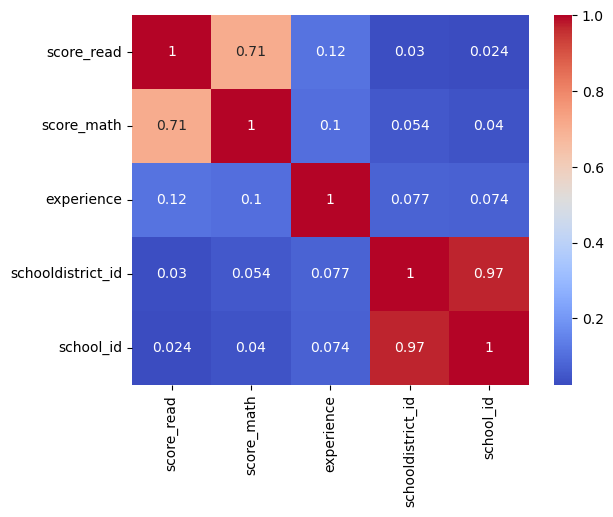

In [30]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')

### 🧮 Categorical Variable Summary

**Why:**  
To understand how balanced each categorical feature is, detect high-cardinality variables, and plan appropriate encoding strategies.

**Method:**  
For each categorical column, calculated:
- Number of unique categories
- Proportion of each category

**Key Findings:**
- Most categorical variables have 2–6 categories (manageable for one-hot encoding).
- `birth` has many unique values (16) — high cardinality, may need grouping.
- Some variables show imbalance:
  - `ladder`: 75% Level1, few higher levels → merge rare ones.
  - `t_ethnicity` and `ethnicity`: dominated by ‘cauc’ group → note bias risk.
- `gender`, `lunch`, and `class_type` are well balanced.

**Action Plan:**
- Combine rare categories (<1%) into "Other".
- Drop or simplify highly unique categorical features.
- One-hot encode balanced categorical variables.
- Document category proportions for interpretability and fairness.


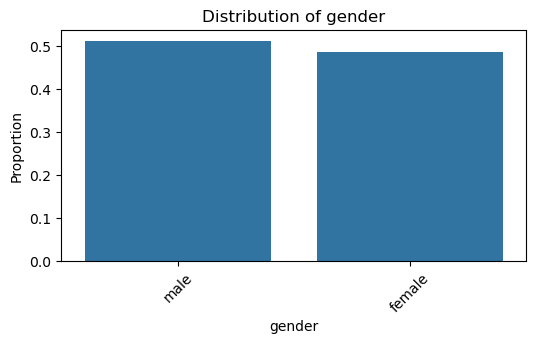

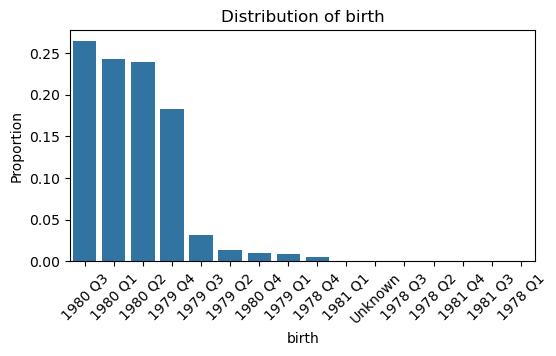

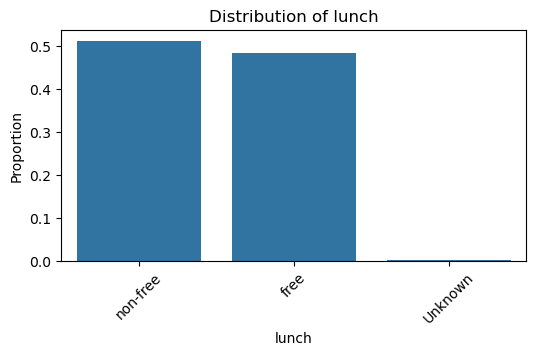

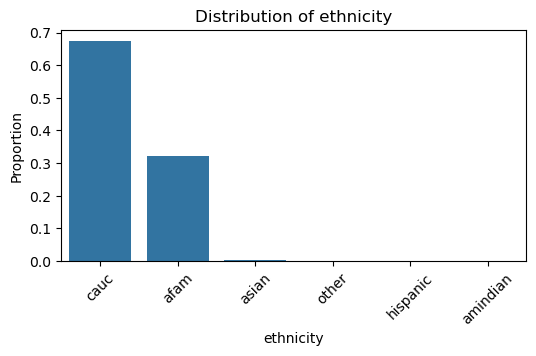

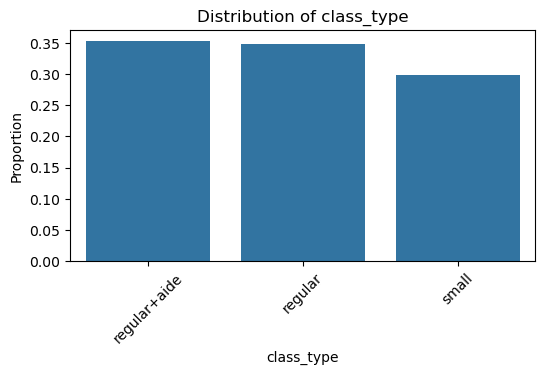

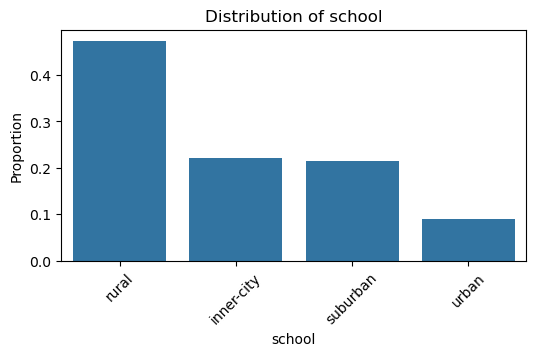

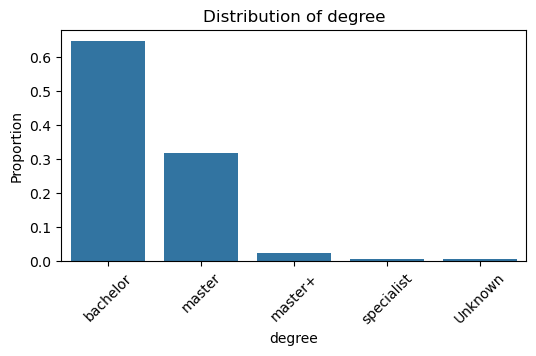

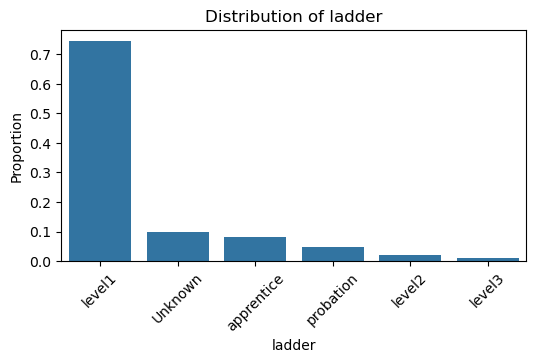

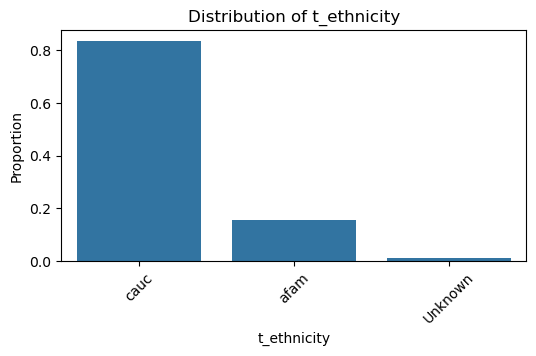

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# set up grid for multiple categorical plots
for col in categorical_cols:
    plt.figure(figsize=(6, 3))
    order = df[col].value_counts().index  # order by frequency
    sns.barplot(x=df[col].value_counts(normalize=True).index,
                y=df[col].value_counts(normalize=True).values)
    plt.title(f"Distribution of {col}")
    plt.ylabel("Proportion")
    plt.xticks(rotation=45)
    plt.show()


In [48]:
import pandas as pd

# Create a summary DataFrame for categorical columns
cat_summary = []

for col in categorical_cols:
    value_counts = df[col].value_counts(normalize=True).round(3)  # proportion
    n_unique = df[col].nunique()
    top_categories = ", ".join([f"{idx} ({val:.2f})" for idx, val in value_counts.items()])

    cat_summary.append({
        'Column': col,
        'Unique Count': n_unique,
        'Category Distribution (Proportion)': top_categories
    })

cat_summary_df = pd.DataFrame(cat_summary)
cat_summary_df


,Column,Unique Count,Category Distribution (Proportion)
0,gender,2,"male (0.51), female (0.49)"
1,birth,16,"1980 Q3 (0.26), 1980 Q1 (0.24), 1980 Q2 (0.24)..."
2,lunch,3,"non-free (0.51), free (0.48), Unknown (0.00)"
3,ethnicity,6,"cauc (0.67), afam (0.32), asian (0.00), other ..."
4,class_type,3,"regular+aide (0.35), regular (0.35), small (0.30)"
5,school,4,"rural (0.47), inner-city (0.22), suburban (0.2..."
6,degree,5,"bachelor (0.65), master (0.32), master+ (0.02)..."
7,ladder,6,"level1 (0.74), Unknown (0.10), apprentice (0.0..."
8,t_ethnicity,3,"cauc (0.83), afam (0.15), Unknown (0.01)"


### 🔍 Categorical vs Numeric Summary Insights

**Goal:** Understand how categorical variables influence student performance in reading (`score_read`) and math (`score_math`).

**Findings:**
- **Lunch type:** Strongest predictor; students with non-free lunch scored ~17–23 points higher.
- **School type:** Suburban students outperform inner-city ones (~20-point difference).
- **Ladder level:** Higher teaching levels correspond with higher student scores.
- **Gender:** Females perform slightly better in both reading and math.
- **Degree:** Minor positive trend with higher teacher qualifications.
- **Birth & ethnicity:** Many small or rare categories — will merge or drop later.

**Next Steps:**
- Collapse rare categories into “Other.”
- Encode categorical variables appropriately for modeling.
- Consider significance testing to validate key differences (e.g., ANOVA).


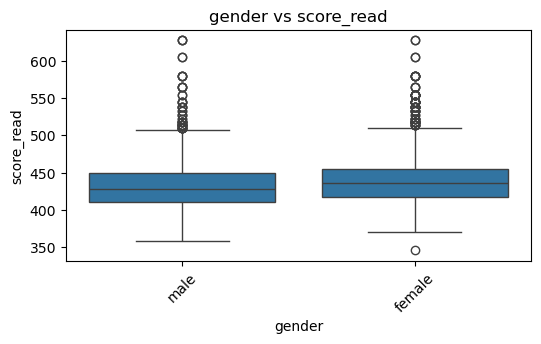

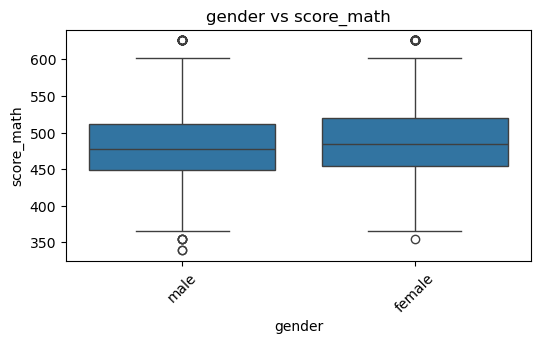

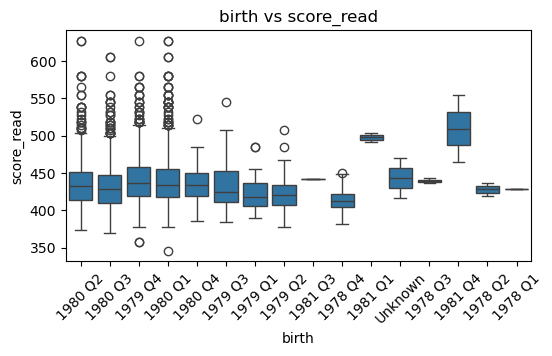

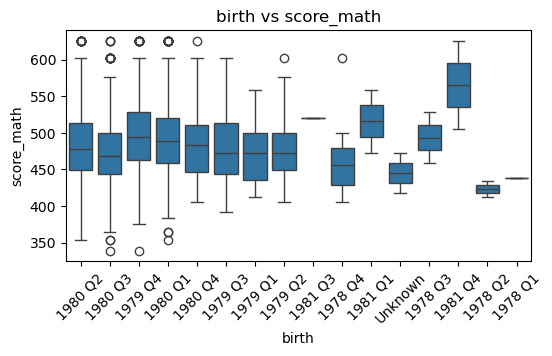

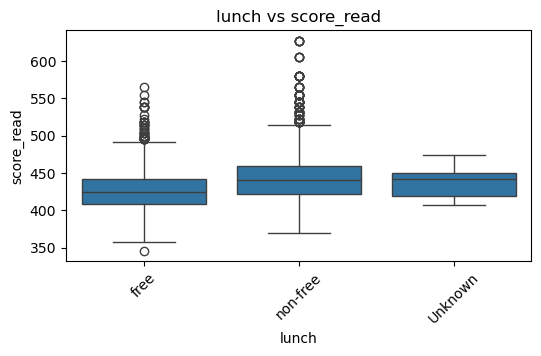

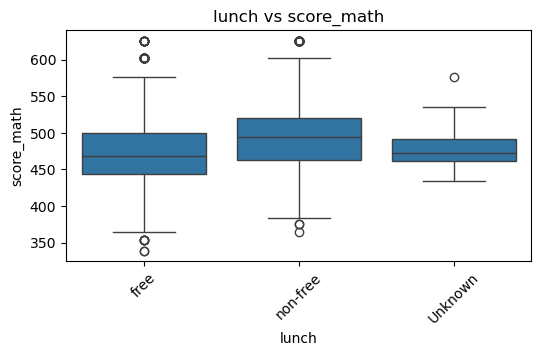

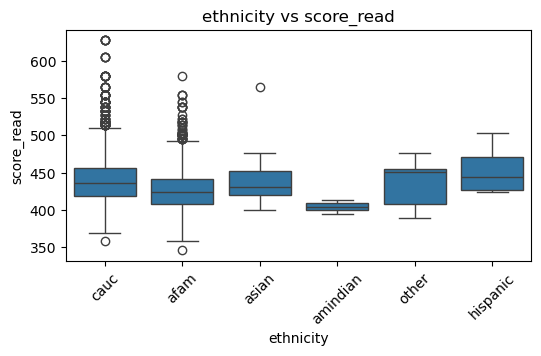

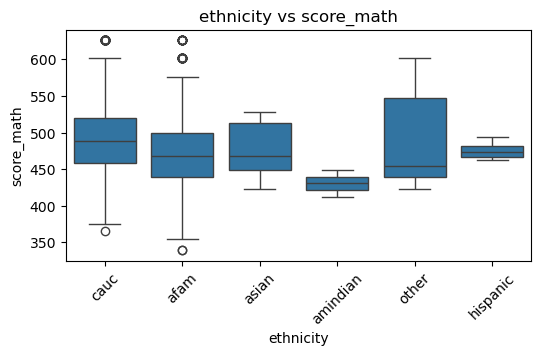

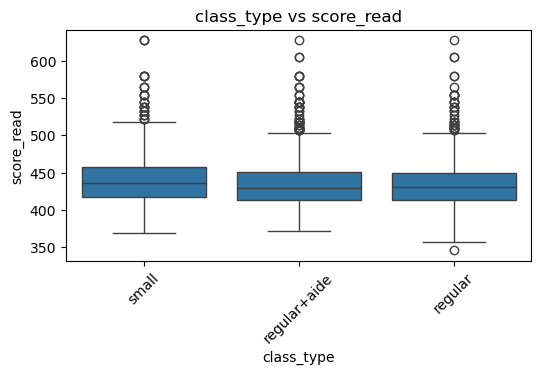

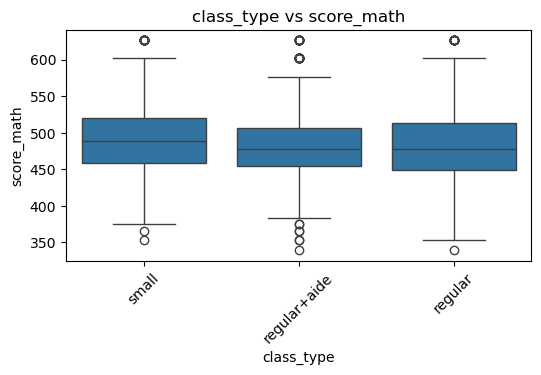

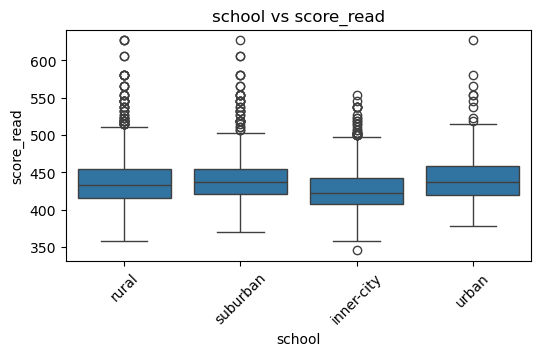

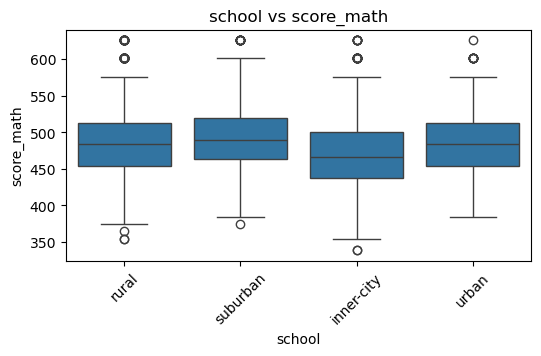

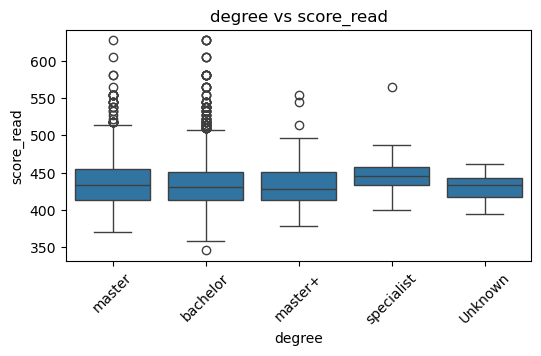

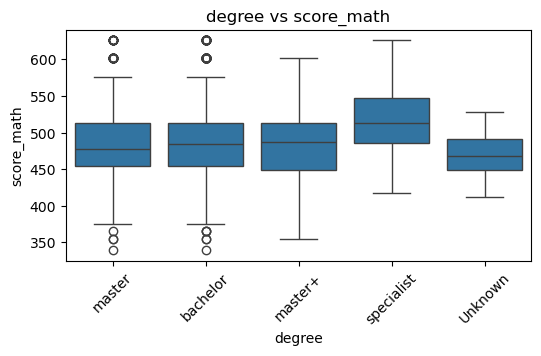

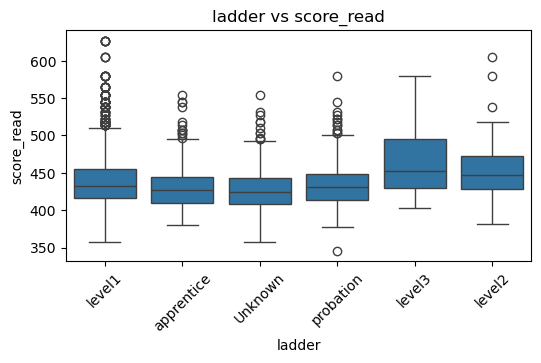

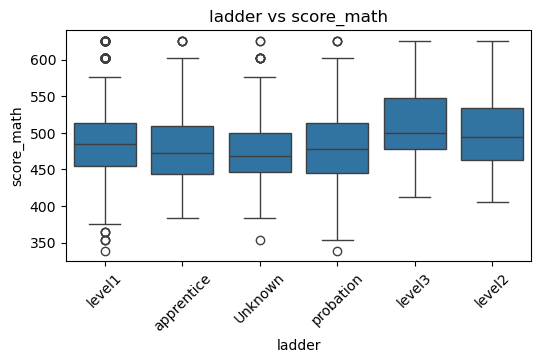

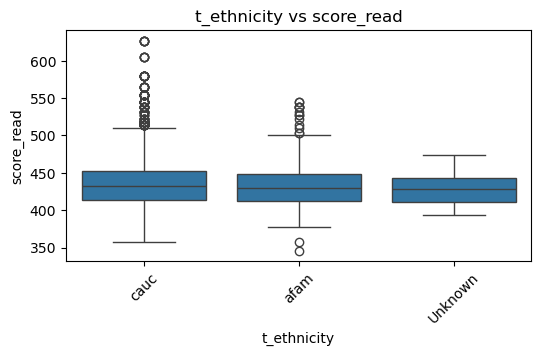

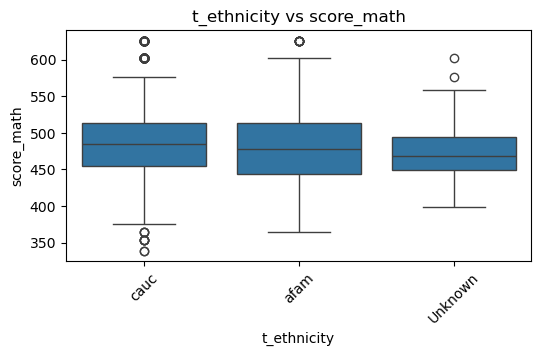

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in categorical_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=col, y='score_read', data=df)
    plt.title(f'{col} vs score_read')
    plt.xticks(rotation=45)
    plt.show()

    plt.figure(figsize=(6, 3))
    sns.boxplot(x=col, y='score_math', data=df)
    plt.title(f'{col} vs score_math')
    plt.xticks(rotation=45)
    plt.show()


In [44]:
import pandas as pd

targets = ['score_read', 'score_math']
categorical_cols = df.select_dtypes(exclude='number').columns

rows = []
for col in categorical_cols:
    # per-category stats
    agg = (
        df.groupby(col)[targets]
          .agg(['mean','median','std','count'])
          .round(2)
    )
    # flatten multiindex columns
    agg.columns = [f"{t}_{stat}" for t, stat in agg.columns]
    agg = agg.reset_index().rename(columns={col:'category'})
    agg.insert(0, 'variable', col)

    # add category proportion within this variable
    prop = df[col].value_counts(normalize=True)
    agg['proportion'] = agg['category'].map(prop).round(3)

    # small-sample flag (use whichever target has fewer rows)
    agg['small_sample'] = agg[[f'{t}_count' for t in targets]].min(axis=1) < 30

    rows.append(agg)

cat_num_tidy = pd.concat(rows, ignore_index=True)

# nice column order
cat_num_tidy = cat_num_tidy[
    ['variable','category','proportion',
     'score_read_mean','score_read_median','score_read_std','score_read_count',
     'score_math_mean','score_math_median','score_math_std','score_math_count',
     'small_sample']
]

cat_num_tidy



,variable,category,proportion,score_read_mean,score_read_median,score_read_std,score_read_count,score_math_mean,score_math_median,score_math_std,score_math_count,small_sample
0,gender,female,0.488,439.32,436.0,32.12,2262,489.39,484.0,47.78,2262,False
1,gender,male,0.512,433.38,428.0,30.36,2378,481.55,478.0,47.16,2378,False
2,birth,1978 Q1,0.000,428.00,428.0,NaN,1,439.00,439.0,NaN,1,True
3,birth,1978 Q2,0.000,428.00,428.0,12.73,2,423.00,423.0,15.56,2,True
4,birth,1978 Q3,0.000,439.50,439.5,4.95,2,493.50,493.5,48.79,2,True
5,birth,1978 Q4,0.005,414.21,412.0,17.41,24,459.67,456.5,40.49,24,True
6,birth,1979 Q1,0.008,423.71,417.5,23.66,38,470.53,473.0,37.68,38,False
7,birth,1979 Q2,0.014,423.94,421.0,22.51,65,478.31,473.0,44.20,65,False
8,birth,1979 Q3,0.031,432.75,425.0,27.91,145,482.38,473.0,50.44,145,False
9,birth,1979 Q4,0.183,441.95,437.0,32.90,848,497.86,494.0,49.17,848,False


### 🔗 Numeric Correlations

**Findings:**
- Strong positive correlation between reading and math scores (r = 0.71).  
- Very high redundancy between `school_id` and `schooldistrict_id` (r = 0.97) → one can be dropped.  
- Weak positive correlation between `experience` and both scores.

**Conclusion:**
The correlation heatmap provides sufficient insight; pairplot is redundant and can be omitted.


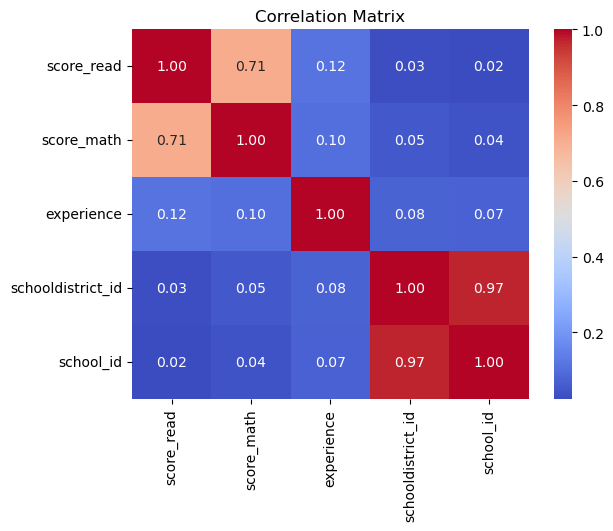

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation Heatmap (quantitative relationships)
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()


### 🧩 Multicollinearity (VIF Analysis)

**Findings:**
| Variable | VIF | Interpretation |
|-----------|------|----------------|
| experience | 2.33 | Acceptable — no multicollinearity |
| schooldistrict_id | 66.94 | Severe multicollinearity |
| school_id | 68.14 | Severe multicollinearity |

**Conclusion:**
- `school_id` and `schooldistrict_id` are almost perfectly correlated (r = 0.97).  
- Their VIFs > 60 confirm redundancy.  
- Drop one (preferably `schooldistrict_id`) to prevent instability in regression models.


In [47]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Select only numeric predictors (exclude target variables)
X = df.select_dtypes(include='number').drop(columns=['score_read', 'score_math'])

# Compute VIF for each variable
vif = pd.DataFrame()
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif["Variable"] = X.columns

print(vif)


         VIF           Variable
0   2.331844         experience
1  66.941355  schooldistrict_id
2  68.135617          school_id
